# 04 — O4 : réseau classé et auto-écoles

Ce notebook **visualise** les données qui alimentent les indicateurs de O4. Il ne produit aucun chiffre du 04 : la faisabilité vient de `faisabilite_indicateurs.csv` (`scripts/faisabilite_04.py`), les contrôles de `controles_coherence.csv` et `jointures.csv` (R-19). Aucune lecture causale.

**Ce qu'on regarde** : les auto-écoles par statut d'agrément, les préfectures sans auto-école agréée, et les points de départ de la distance (O4-08).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from IPython.display import display
from style_04 import *
appliquer_style()
pd.set_option("display.max_colwidth", 90)

## Faisabilité des 9 indicateurs

In [2]:
display(faisabilite("O4"))

,Indicateur,Prévu (03),Résultat (04),Maille obtenue,Période,Preuve (04),Réserve
ID,,,,,,,
O4-01,"Km de routes classées, par classe",Cible,Cible,Préfecture,Collecte 2021-2022,B,
O4-02,Densité routière,Cible,Cible,Préfecture,Collecte 2021-2022,B,
O4-03,Km de routes pour 10 000 habitants,Cible,Cible,Préfecture,2022,B,
O4-04,Nombre d’auto-écoles,Cible,Cible,Préfecture,Collecte 2021-2022,A,Activité non vérifiée (écart 13)
O4-05,Auto-écoles pour 100 000 habitants,Cible,Cible,Préfecture,2022,C,Activité non vérifiée (écart 13)
O4-06,Habitants par auto-école,Cible,Cible,Préfecture,2022,C,Activité non vérifiée (écart 13)
O4-07,Préfectures sans auto-école,Cible,Cible,Préfecture,2022,B,Activité non vérifiée (écart 13)
O4-08,Distance à l’auto-école la plus proche,Cible,Repli,Préfecture,Collecte 2021-2022,C,"Distance d'un point par préfecture, pas de la population ; les préfectures mesurées de..."
O4-09,Capacité de formation,Non,Non,—,,—,


## Auto-écoles par statut d'agrément

R-12 : on compte les agréées et les antennes agréées ; leur activité n'est pas vérifiée (écart 13). Les deux panneaux ont la même légende ; le second agrandit le Grand Lomé, où se trouvent la plupart des établissements.

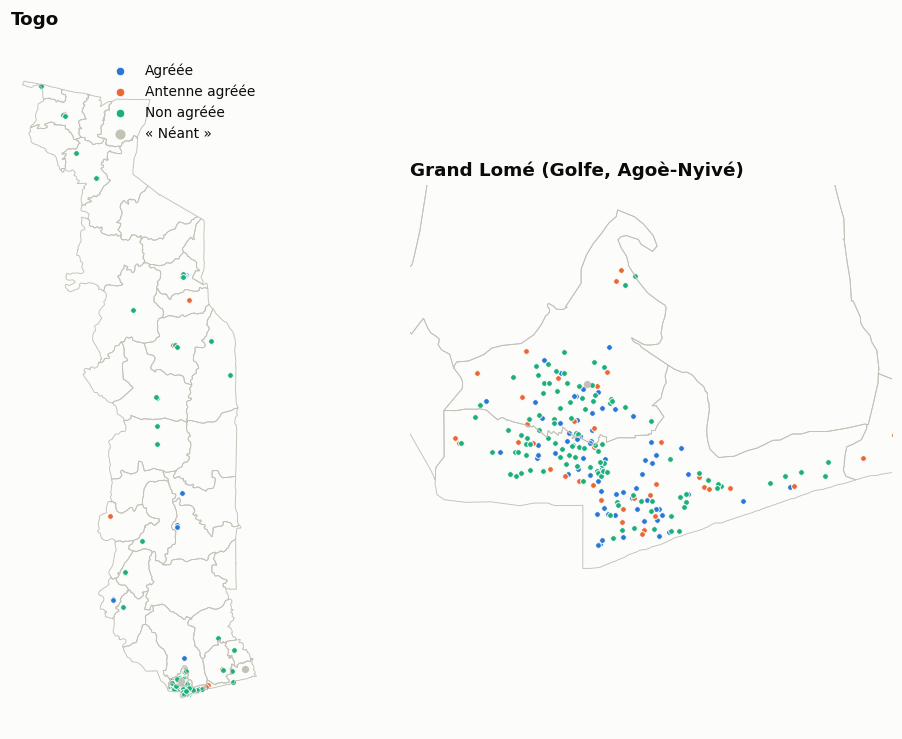

,recensees,agreees
Préfecture,,
Golfe,143,74
Agoè-Nyivé,69,29
Kozah,11,6
Tône,5,3
Kloto,3,3
Wawa,2,2
Vo,3,2
Tchaoudjo,4,2
Sotouboua,4,2


In [3]:
pref = gpd.read_file(INTERIM / "prefectures_2022.geojson").to_crs(UTM31N)
ae = pd.read_csv(INTERIM / "auto_ecoles_prefecture.csv")
ae = gpd.GeoDataFrame(ae, geometry=gpd.points_from_xy(ae["x_utm"], ae["y_utm"]), crs=UTM31N)
statuts = ["Agréée", "Antenne agréée", "Non agréée"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 8), gridspec_kw={"width_ratios": [1, 1.3]})
grand_lome = pref[pref["Zone"] == "Grand Lomé"]
for ax in (ax1, ax2):
    pref.boundary.plot(ax=ax, color=AXE, linewidth=0.6)
    for couleur, s in zip(SERIES, statuts):
        ae[ae["agregation"] == s].plot(ax=ax, color=couleur, markersize=14, edgecolor=SURFACE, linewidth=0.6, label=s)
    ae[~ae["agregation"].isin(statuts)].plot(ax=ax, color=NEUTRE, markersize=14, label="« Néant »")
    ax.set_axis_off()
xmin, ymin, xmax, ymax = grand_lome.total_bounds
ax2.set_xlim(xmin - 2000, xmax + 2000); ax2.set_ylim(ymin - 2000, ymax + 2000)
ax1.set_title("Togo"); ax2.set_title("Grand Lomé (Golfe, Agoè-Nyivé)")
ax1.legend(loc="upper right", fontsize=9, markerscale=1.5)
plt.show()
compte = ae.assign(agreee=ae["agregation"].isin(["Agréée", "Antenne agréée"])).groupby("Préfecture").agg(recensees=("FID", "size"), agreees=("agreee", "sum"))
compte = compte.reindex(sorted(pref["Préfecture"])).fillna(0).astype(int)
display(compte.sort_values("agreees", ascending=False))

## Points de départ de la distance (O4-08)

9 préfectures n'ont aucun chef-lieu dans la couche HDX (contrôle 5-09) : ✅ repli par le point d'étiquette HDX de la préfecture (écart 19, contrôle 5-15), en C. Ces 9 préfectures sont en orange ; le losange marque leur point d'étiquette, le rond un chef-lieu.

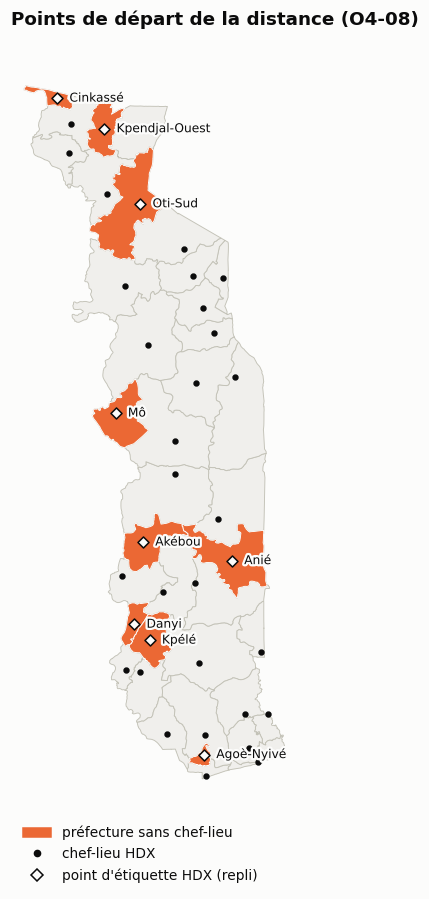

,Préfecture,Point,Origine
0,Agoè-Nyivé,Agoe-Nyive,point d'étiquette HDX
1,Akébou,Akebou,point d'étiquette HDX
2,Anié,Anie,point d'étiquette HDX
3,Cinkassé,Cinkasse,point d'étiquette HDX
4,Danyi,Danyi,point d'étiquette HDX
5,Kpendjal-Ouest,Naki-Ouest,point d'étiquette HDX
6,Kpélé,Kpele,point d'étiquette HDX
7,Mô,Plaine du Mo,point d'étiquette HDX
8,Oti-Sud,Oti-Sud,point d'étiquette HDX


,préfectures
Origine,
chef-lieu HDX,30
point d'étiquette HDX,9


In [4]:
points = pd.read_csv(INTERIM / "points_depart_o4_08.csv")
points = gpd.GeoDataFrame(points, geometry=gpd.points_from_xy(points["x_utm"], points["y_utm"]), crs=UTM31N)
etiquette = points["Origine"] == "point d'étiquette HDX"
sans = pref[pref["Préfecture"].isin(points.loc[etiquette, "Préfecture"])]
fig, ax = plt.subplots(figsize=(6, 9))
pref.plot(ax=ax, color="#f0efec", edgecolor=AXE, linewidth=0.6)
sans.plot(ax=ax, color=SERIES[1], edgecolor=SURFACE, linewidth=0.6)
points[~etiquette].plot(ax=ax, color=ENCRE, markersize=10)
points[etiquette].plot(ax=ax, color=SURFACE, edgecolor=ENCRE, marker="D", markersize=26, linewidth=1)
for _, p in points[etiquette].iterrows():
    ax.annotate(p["Préfecture"], (p.geometry.x, p.geometry.y), xytext=(8, 0), textcoords="offset points", fontsize=8, color=ENCRE, va="center", path_effects=HALO)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=SERIES[1], label="préfecture sans chef-lieu"),
                   Line2D([], [], marker="o", linestyle="", color=ENCRE, markersize=4, label="chef-lieu HDX"),
                   Line2D([], [], marker="D", linestyle="", color=SURFACE, markeredgecolor=ENCRE, markersize=6, label="point d'étiquette HDX (repli)")],
          loc="upper left", bbox_to_anchor=(0, 0), fontsize=9)
ax.set_axis_off(); ax.set_title("Points de départ de la distance (O4-08)")
plt.show()
display(points.loc[etiquette, ["Préfecture", "Point", "Origine"]].reset_index(drop=True))
display(points["Origine"].value_counts().to_frame("préfectures"))